<a href="https://colab.research.google.com/github/mini-KK27926/ML_Game_of_Thrones/blob/main/Game_of_Thrones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В данном проекте мы будем работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Необходимо предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

## Часть 1. Анализ и предобработка данных


* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 60.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 90.4MB/s]


**Задание 1.1.** Импортируем библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загружаем датасет в Pandas DataFrame при помощи функции `read_csv`

In [ ]:
data = pd.read_csv("/content/game_of_thrones_train.csv", index_col="S.No")
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


Посмотрим, какие типы данных представлены в нашем датасете



Посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe()
- для удобства восприятия транспонируем таблицу

In [ ]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных


In [ ]:
data.describe(include = ["int","float"]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

In [ ]:
data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


В этом проекте удалять строки с NaN (dropna) мы не будем по следующим причинам:
- В обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- В тестовом датасете также много признаков с NaN . Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Построим гистограмму распределения данного признака с количеством интервалов (bins), равным 50

(array([628., 337., 161., 116.,  67.,  41.,  56.,  32.,  27.,   9.,   8.,
         10.,   5.,   9.,   3.,   3.,   1.,   4.,   3.,   0.,   2.,   2.,
          0.,   3.,   3.,   1.,   0.,   0.,   2.,   0.,   1.,   2.,   1.,
          2.,   0.,   1.,   2.,   1.,   1.,   0.,   0.,   0.,   1.,   0.,
          1.,   0.,   0.,   0.,   1.,  10.]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

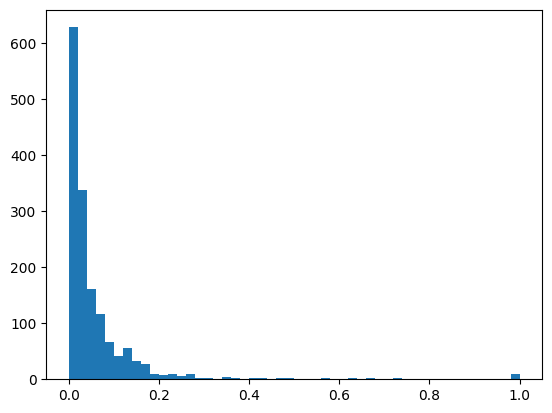

In [ ]:
plt.hist(data["popularity"], bins = 50)

Распределение сильно несимметрично. Преобразуем данный признак по формуле `np.log10(data["popularity"]*M+1)`

In [ ]:
import numpy as np
data["popularity"] = np.log10(data["popularity"]*100+1)

(array([ 82.,   0.,   0.,  87.,   0., 113.,   0., 102.,   0., 126., 118.,
         81.,   0.,  82.,  69.,  74.,  31.,  27.,  70.,  29.,  35.,  47.,
         37.,  48.,  39.,  12.,  32.,  18.,  35.,  34.,  26.,  12.,   8.,
          8.,  10.,   7.,  10.,   3.,   3.,   5.,   3.,   2.,   6.,   1.,
          4.,   3.,   3.,   2.,   2.,  11.]),
 array([0.        , 0.04008643, 0.08017285, 0.12025928, 0.16034571,
        0.20043214, 0.24051856, 0.28060499, 0.32069142, 0.36077785,
        0.40086427, 0.4409507 , 0.48103713, 0.52112356, 0.56120998,
        0.60129641, 0.64138284, 0.68146927, 0.72155569, 0.76164212,
        0.80172855, 0.84181498, 0.8819014 , 0.92198783, 0.96207426,
        1.00216069, 1.04224711, 1.08233354, 1.12241997, 1.1625064 ,
        1.20259282, 1.24267925, 1.28276568, 1.32285211, 1.36293853,
        1.40302496, 1.44311139, 1.48319782, 1.52328424, 1.56337067,
        1.6034571 , 1.64354353, 1.68362995, 1.72371638, 1.76380281,
        1.80388924, 1.84397566, 1.88406209, 1.

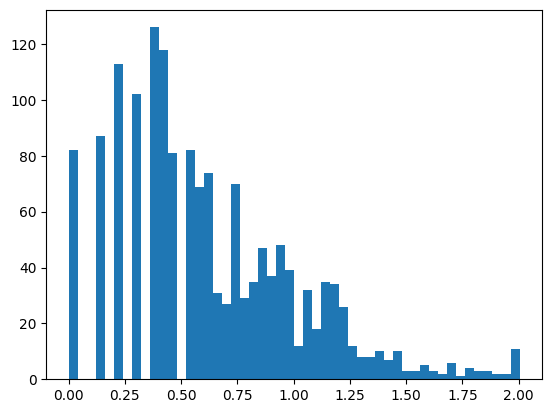

In [ ]:
plt.hist(data["popularity"], bins = 50)

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрим на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создем признак `boolDeadRelations`. Упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [ ]:
data["boolDeadRelations"] = (data["numDeadRelations"] > 0).astype(int)
data.drop("numDeadRelations",axis=1)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,popularity,isAlive,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,1.789123,0,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1.957282,1,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,1.443355,1,0
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,1.287682,0,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0.728177,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1553,Marwyn,Archmaester,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,1.231814,1,0
1554,Masha Heddle,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0.700130,0,0
1555,Matthos Seaworth,NaN,1,NaN,NaN,NaN,NaN,NaN,House Seaworth,NaN,...,NaN,NaN,NaN,NaN,0,0,NaN,0.939135,0,0


Давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.     

In [ ]:
data['age_value'] = [0 if np.isnan(x) else 1 for x in data['age']]
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]
data.drop(columns = ["age"],inplace=True)
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,numDeadRelations,popularity,isAlive,boolDeadRelations,age_value,age_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,0.0,NaN,0,0,11,1.789123,0,1,0,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,1.0,1,1,1,1.957282,1,1,1,0
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,0,1,0,1.443355,1,0,0,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,0.0,1,1,0,1.287682,0,0,1,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,1.0,1,1,0,0.728177,1,0,1,0


**Задание 1.5.** Категориальные признаки с большим количеством категорий

In [ ]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [ ]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [ ]:
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
    cultures_grouped_inverted.update({v:k})
cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()`

In [ ]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [ ]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

In [ ]:
data.drop(columns = ["culture"],inplace=True)
data.head()

,name,title,male,dateOfBirth,mother,father,heir,house,spouse,book1,...,isAliveSpouse,isMarried,isNoble,numDeadRelations,popularity,isAlive,boolDeadRelations,age_value,age_no_data,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,0,...,NaN,0,0,11,1.789123,0,1,0,1,culture_no_data
2,Walder Frey,Lord of the Crossing,1,208.0,NaN,NaN,NaN,House Frey,Perra Royce,1,...,1.0,1,1,1,1.957282,1,1,1,0,the Isles and Rivers
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,House Swyft,NaN,0,...,NaN,0,1,0,1.443355,1,0,0,1,culture_no_data
4,Aemma Arryn,Queen,0,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,0,...,0.0,1,1,0,1.287682,0,0,1,0,culture_no_data
5,Sylva Santagar,Greenstone,0,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,0,...,1.0,1,1,0,0.728177,1,0,1,0,Dorne


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1557 non-null   object 
 1   title              717 non-null    object 
 2   male               1557 non-null   int64  
 3   dateOfBirth        279 non-null    float64
 4   mother             18 non-null     object 
 5   father             22 non-null     object 
 6   heir               21 non-null     object 
 7   house              1176 non-null   object 
 8   spouse             200 non-null    object 
 9   book1              1557 non-null   int64  
 10  book2              1557 non-null   int64  
 11  book3              1557 non-null   int64  
 12  book4              1557 non-null   int64  
 13  book5              1557 non-null   int64  
 14  isAliveMother      18 non-null     float64
 15  isAliveFather      22 non-null     float64
 16  isAliveHeir        21 non-nul

In [ ]:
data['culture_grouped'].value_counts(dropna=False)

,count
culture_grouped,
culture_no_data,1069
Essos Nations,109
the North,108
the Iron Islands,95
Other Nations,57
Old Nations,32
the Mountain and the Vale,25
Dorne,21
the Rock,14


In [ ]:
from sklearn.preprocessing import OneHotEncoder


if 'culture_grouped' in data.columns:
    # 1. Объединяем мелкие группы
    counts = data['culture_grouped'].value_counts()
    small_groups = counts[counts < 15].index
    data.loc[data['culture_grouped'].isin(small_groups), 'culture_grouped'] = 'Other Nations'
    # 2. Инициализируем энкодер
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_data = encoder.fit_transform(data[['culture_grouped']])
    # 3. Получаем имена корректно (сначала с префиксами, потом чистим)
    feature_names = encoder.get_feature_names_out(['culture_grouped'])
    clean_names = [name.replace('culture_grouped_', '') for name in feature_names]
    encoded_df = pd.DataFrame(encoded_data, columns=clean_names)
    # 4. Склеиваем с основным датасетом и удаляем старую колонку
    data = pd.concat([data.drop('culture_grouped', axis=1), encoded_df], axis=1)

In [ ]:
data

,name,title,male,dateOfBirth,mother,father,heir,house,spouse,book1,...,boolDeadRelations,age_value,age_no_data,Essos Nations,Old Nations,Other Nations,culture_no_data,the Iron Islands,the Mountain and the Vale,the North
1,Viserys II Targaryen,NaN,1.0,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,Walder Frey,Lord of the Crossing,1.0,208.0,NaN,NaN,NaN,House Frey,Perra Royce,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Addison Hill,Ser,1.0,NaN,NaN,NaN,NaN,House Swyft,NaN,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Aemma Arryn,Queen,0.0,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Sylva Santagar,Greenstone,0.0,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1554,Masha Heddle,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1555,Matthos Seaworth,NaN,1.0,NaN,NaN,NaN,NaN,House Seaworth,NaN,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1556,Meera Reed,NaN,0.0,283.0,NaN,NaN,NaN,House Reed,NaN,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1557,Melara Hetherspoon,NaN,0.0,264.0,NaN,NaN,NaN,House Hetherspoon,NaN,0.0,...,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Задание 1.6.** Категориальные признаки
Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

In [ ]:
# Количество уникальных значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186
book1,2


In [ ]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
data.describe(include = ["int","float"]).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.000000,2
dateOfBirth,279.0,-25.0,299.000000,105
book1,1557.0,0.0,1.000000,2
book2,1557.0,0.0,1.000000,2
book3,1557.0,0.0,1.000000,2
book4,1557.0,0.0,1.000000,2
book5,1557.0,0.0,1.000000,2
isAliveMother,18.0,0.0,1.000000,2
isAliveFather,22.0,0.0,1.000000,2
isAliveHeir,21.0,0.0,1.000000,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, их потребуется обработать.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1558 entries, 1 to 0
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       1557 non-null   object 
 1   title                      717 non-null    object 
 2   male                       1557 non-null   float64
 3   dateOfBirth                279 non-null    float64
 4   mother                     18 non-null     object 
 5   father                     22 non-null     object 
 6   heir                       21 non-null     object 
 7   house                      1176 non-null   object 
 8   spouse                     200 non-null    object 
 9   book1                      1557 non-null   float64
 10  book2                      1557 non-null   float64
 11  book3                      1557 non-null   float64
 12  book4                      1557 non-null   float64
 13  book5                      1557 non-null   float64
 14  

In [ ]:

data.groupby('isAliveSpouse', dropna = False)['isAlive'].mean()

,isAlive
isAliveSpouse,
0.0,0.619048
1.0,0.753165
NaN,0.786293


**Задание 1.7.** Анализируем признаки.



Проанализируем колонку title

In [ ]:
data['title'].value_counts(dropna=False)

In [ ]:
# Заполняем пропуски, чтобы не было ошибки при поиске
data['title'] = data['title'].fillna('No title')

# Создаем функцию для определения знатности
def classify_noble(title):
    noble_keywords = ['lord', 'lady', 'king', 'queen', 'prince', 'princess', 'ser', 'knight', 'maester', 'hand']
    title_lower = title.lower()

    # Если хоть одно ключевое слово есть в титуле, значит знатный
    if any(keyword in title_lower for keyword in noble_keywords):
        return 1
    else:
        return 0

In [ ]:
data['is_noble_title'] = data['title'].apply(classify_noble)
data.drop(columns=["title"], inplace=True)
data['is_noble_title'].value_counts()

Проанализируем колонки

In [ ]:
alive_cols = ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']

for col in alive_cols:
    data[col] = data[col].fillna(-1)

In [ ]:
data.info()

In [ ]:
data.drop(columns = ["name"],inplace=True)

In [ ]:
data.head()

**Задание 1.8.** Проанализируем влияние признаков на целевую переменную.

In [ ]:
data.groupby('is_noble_title', dropna = False)['isAlive'].mean()

In [ ]:
data.head()

**Задание 1.9.** Создаем переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
text_cols = ['mother', 'father', 'heir', 'house', 'spouse']
data = data.drop(columns=[col for col in text_cols if col in data.columns])
data = data.fillna(0)

X = data.drop(['isAlive'], axis=1)
y = data['isAlive']

**Задание 1.10.** Делим датасет на обучащую и валидационные части (train и val) при помощи функции `train_test_split`

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Часть 2. Обучение моделей

В этом проекте мы будем работать с моделью `LogisticRegression`

In [ ]:
from sklearn.linear_model import LogisticRegression

**Задание 2.2.** Обучаем модель и делаем предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
model = LogisticRegression()

# Шаг 2. обучение модели
model.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val)

## Часть 3. Оцените качество моделей

Для оценки качества модели поработаем с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val)
# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [ ]:
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col="S.No")

In [ ]:
data_test.head()

По аналогии с тем, как мы работали с обучающим датасетом, посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [ ]:
data_test.loc[data_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

In [ ]:
data_test.loc[1685, 'dateOfBirth'] = 278
data_test.loc[1869,'dateOfBirth'] = 278

Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [ ]:
import numpy as np
data_test["popularity"] = np.log10(data["popularity"]*100+1)

In [ ]:
data_test["boolDeadRelations"] = (data_test["numDeadRelations"] > 0).astype(int)
data_test.drop("numDeadRelations",axis=1)

In [ ]:
data_test['age_value'] = [0 if np.isnan(x) else 1 for x in data_test['age']]
data_test['age_no_data'] = [1 if np.isnan(x) else 0 for x in data_test['age']]
data_test.drop(columns = ["age"],inplace=True)
data_test.head()

In [ ]:
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)

In [ ]:
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

In [ ]:
data_test.drop(columns = ["culture"],inplace=True)
data_test.head()

In [ ]:
if 'culture_grouped' in data_test.columns:
    # 1. Объединяем мелкие группы
    counts = data_test['culture_grouped'].value_counts()
    small_groups = counts[counts < 15].index

    data_test.loc[data_test['culture_grouped'].isin(small_groups), 'culture_grouped'] = 'Other Nations'

    # 2. Используем .transform() с уже обученным encoder
    encoded_data = encoder.transform(data_test[['culture_grouped']])

    # 3. Получаем имена
    feature_names = encoder.get_feature_names_out(['culture_grouped'])
    clean_names = [name.replace('culture_grouped_', '') for name in feature_names]

    encoded_df = pd.DataFrame(encoded_data, columns=clean_names, index=data_test.index)

    # 4. Склеиваем с тестовым датасетом и удаляем старую колонку
    data_test = pd.concat([data_test.drop('culture_grouped', axis=1), encoded_df], axis=1)

In [ ]:
# Заполняем пропуски, чтобы не было ошибки при поиске
data_test['title'] = data_test['title'].fillna('No title')

# Создаем функцию для определения знатности
def classify_noble(title):
    noble_keywords = ['lord', 'lady', 'king', 'queen', 'prince', 'princess', 'ser', 'knight', 'maester', 'hand']
    title_lower = title.lower()

    # Если хоть одно ключевое слово есть в титуле, значит знатный
    if any(keyword in title_lower for keyword in noble_keywords):
        return 1
    else:
        return 0

In [ ]:
text_cols = ['mother', 'father', 'heir', 'house', 'spouse']
data_test = data_test.drop(columns=[col for col in text_cols if col in data_test.columns])
data_test = data_test.fillna(0)

In [ ]:
data_test['is_noble_title'] = data_test['title'].apply(classify_noble)
data_test.drop(columns=["title"], inplace=True)
data_test['is_noble_title'].value_counts()

In [ ]:
data_test.drop(columns = ["name"],inplace=True)

In [ ]:
pred = model.predict(data_test)

In [ ]:
pred

### Файл `submission.csv`

Вместо значений в `submission.csv` файле в колонке `isAlive`, подставим полученные предсказания и сохраним измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

"gdown" ­Ґ пў«пҐвбп ў­гваҐ­­Ґ© Ё«Ё ў­Ґи­Ґ©
Є®¬ ­¤®©, ЁбЇ®«­пҐ¬®© Їа®Ја ¬¬®© Ё«Ё Ї ЄҐв­л¬ д ©«®¬.


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission['isAlive'] = pred

In [ ]:
submission.to_csv("/content/new_submission.csv", index=False)

Посчитаем метрику Accurancy

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, submission['isAlive'])

print(f"Accuracy решения: {accuracy:.4f}")